In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

In [ ]:
# Make the datasets
# If loading in a dataset, comment this cell

#datasets=np.load('curated_data/speckle_datasets.npy') # If generating your own data, change to 'user_created_data/speckle_datasets.npy'

np.random.seed(101)
#imax = 10000 # 10000 images is a good benchmark. Easily run on a 32GB computer, but the same OoM as datasets like MNIST
imax = 10000
dim = 64   # Test images are CiFAR10. CiFAR10 is 32x32

# 1. Setup coordinates
x=np.linspace(-10,10,dim)
X,Y=np.meshgrid(x,x)
R2 = X**2 + Y**2


dataset=np.zeros((imax,dim,dim))
dist = 4.1


for j in range(imax):
    # Generate the random phase (the internal "texture")
    RandP = np.random.uniform(size = [dim,dim]) # Noise

    dataset[j] = np.abs(np.fft.fft2(R2/dist*np.exp(-R2/dist)*np.exp(1j*2*np.pi*RandP)))

plt.imshow(dataset[50],cmap='magma') # This is just some random image from the dataset
plt.axis('off')
plt.show()

In [5]:
# Discreet Wavelet Transform version of the vortex function
def wavelet_distillation(distilled_image):
    # Perform a 2D Discrete Wavelet Transform
    # 'haar' is great for detecting intensity jumps (tumor boundaries)
    coeffs2 = pywt.dwt2(distilled_image, 'haar')
    LL, (LH, HL, HH) = coeffs2
    
    # LL is the 'Approximation' (the general shape)
    # LH, HL, HH are 'Details' (the edges/texture)
    
    # We can stack these to create a multi-resolution feature map
    # This gives the model 4x the 'logic' to work with
    wavelet_stack = np.block([
        [LL, LH],
        [HL, HH]
    ])
    
    return wavelet_stack



# Fast Fourier Transform version of the vortex function
def myfft2(A): 
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))


In [6]:
def generate_vortex_map(f, A, m, dim=64, xmax=10, flambda=80):
    """
    Applies a vortex phase of charge 'm' to a batch of images 'A'.
    
    Parameters:
    A (ndarray): Input image batch of shape [num_images, dim, dim]
    m (int): Topological charge (1, 2, 3, etc.)
    dim (int): Pixel resolution of the grid
    xmax (float): Physical limit of the f-plane
    flambda (float): Lens parameter
    
    Returns:
    ndarray: Processed and normalized images of shape [num_images, dim, dim]
    """
    # 1. Setup Coordinates
    dx = 2 * xmax / dim
    x = np.linspace(-xmax, xmax - dx, dim)
    X, Y = np.meshgrid(x, x)
    R2 = (X**2 + Y**2)
    T = np.arctan2(Y, X)

    # 2. Create the LG Mask (Lens + Vortex Phase)
    Lens = np.exp(-1j * R2 / (flambda / 10))
    Vortex = np.exp(1j * m * T)
    LG_mask = Lens * Vortex

    # 3. Process the Batch
    num_images = A.shape[0]
    out = np.zeros_like(A, dtype=np.float64)
    
    for i in range(num_images):
        # Apply phase modulation and distillation 
        # (Assumes wavelet_distillation is defined globally)
        phase_mod = np.exp(1j * A[i] * np.pi * 2)
        distilled = f(phase_mod * LG_mask)
        
        # Calculate Magnitude
        A_mag = np.abs(distilled)
        
        # Normalize to [-1, 1] for NN compatibility
        a_min = np.amin(A_mag)
        a_diff = np.amax(A_mag) - a_min
        
        if a_diff != 0:
            out[i] = (A_mag - a_min) / a_diff * 2 - 1
        else:
            out[i] = A_mag - a_min

    return out

In [ ]:
# 1. Normalize the ground truth dataset [0, 1]
# imax is your total number of images
gt = np.zeros((imax, dim, dim))

for j in range(imax):
    # Local normalization for each speckle pattern
    d_min = np.amin(dataset[j])
    d_max = np.amax(dataset[j] - d_min)
    
    if d_max != 0:
        gt[j] = (dataset[j] - d_min) / d_max
    else:
        gt[j] = dataset[j] - d_min


In [ ]:
def base_model():
    model = Sequential()
    model.add(Dense(dim ** 2, input_dim= dim ** 2, activation='linear', use_bias=False))  
    model.compile(loss='MSE', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
# Train and save the model

model = base_model()

for transform in [wavelet_distillation, myfft2]:
    for i in range(1, 6, 1):
        # 1. Process through the vortex function for m=1
        # (Assuming 'generate_vortex_map' is the function from the previous step)
        X = generate_vortex_map(transform, gt, m=i)

        # 2. Reshape for the Neural Network (Flattening the spatial dimensions)
        # This converts [imax, 64, 64] -> [imax, 4096]
        X_train = X.reshape(X.shape[0], -1)
        Y_train = gt.reshape(gt.shape[0], -1)

        model.fit(X_train, Y_train, validation_split=0.01, shuffle = True, verbose = 1, batch_size = 784*60, epochs=5000)

        file_path = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/Wavelet/2pi/'
        model.save(file_path + f'{transform.__name__}_m_{i}.keras')

In [7]:
from tensorflow.keras.utils import to_categorical

DIM = 256           # Image dimension 
NUM_CLASSES = 4     # Number of tumor categories


def load_and_preprocess_data(data_dir):
    """Loads images as a dataset, converts to NumPy, and gets integer labels."""
    print(f"Loading data from: {data_dir}")

    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int', # Load as integers
        image_size=(DIM, DIM),
        batch_size=None, # Load all data into one tensor
        shuffle=False
    )
    # Convert to NumPy array
    # x shape will be (N, DIM, DIM, 3)
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    
    return x, y


# Load preprocessed training and testing data
x_train, y_train = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Training/')
x_test, y_test = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Testing/')

# Number of training and testing samples
n_train, n_test = x_train.shape[0], x_test.shape[0]

print(f"\nTraining Samples: {n_train}, Testing Samples: {n_test}")


def convert_to_grayscale_batch(images_rgb_batch, N_samples):
    """Converts a batch of (N, H, W, 3) images to (N, H, W, 1) grayscale using cv2."""
    # Initialize an empty array for the final grayscale data
    images_gray_batch = np.empty((N_samples, DIM, DIM, 1), dtype=np.float32)

    # Loop through the batch and apply the conversion image-by-image
    for i in tqdm(range(N_samples), desc="Converting to Grayscale"):
        # OpenCV needs uint8 format (0-255)
        image_uint8 = images_rgb_batch[i].astype(np.uint8)
        
        # Perform the conversion (Output is 2D: H x W)
        gray_2d = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
        
        # Add the channel dimension back and store (Shape: H x W x 1)
        images_gray_batch[i] = gray_2d[..., np.newaxis]
        
    return images_gray_batch

# Normalize to [0, 1] range
x_train = convert_to_grayscale_batch(x_train, n_train) / 255.0
x_test = convert_to_grayscale_batch(x_test, n_test) / 255.0


def downsample_batch(images_batch, target_dim):
    """Resizes a batch of images from (N, 256, 256) to (N, target_dim, target_dim)."""
    print(f"Downsampling images from {images_batch.shape[1]}x{images_batch.shape[2]} to {target_dim}x{target_dim}...")
    
    downsampled_images = np.empty((images_batch.shape[0], target_dim, target_dim), dtype=np.float32)
    
    # Loop and resize each image
    for i in tqdm(range(images_batch.shape[0]), desc="Resizing Images"):
        # The INTER_AREA interpolation is best for shrinking images
        downsampled_images[i] = cv2.resize(images_batch[i], 
                                           (target_dim, target_dim), 
                                           interpolation=cv2.INTER_AREA)
    return downsampled_images


DIM = 64  # New dimension after downsampling-

# X_train_vort_input is now (N, 32, 32)
x_train = downsample_batch(x_train, DIM)
x_test = downsample_batch(x_test, DIM)


# Lablels
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

# Remove the single channel dimension (axis=-1) for the 'vort_THIS' function.
print(x_train.shape, x_test.shape)
#x_train = np.squeeze(x_train, axis=-1)
#x_test = np.squeeze(x_test, axis=-1)

Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Training/
Found 5712 files belonging to 4 classes.


I0000 00:00:1771569371.472149   22928 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6730 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-02-19 22:36:33.705862: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Testing/
Found 1311 files belonging to 4 classes.


2026-02-19 22:36:43.773022: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-19 22:36:46.508228: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Training Samples: 5712, Testing Samples: 1311


...

Downsampling images from 256x256 to 64x64...


Resizing Images: 100%|██████████| 5712/5712 [00:00<00:00, 11060.20it/s]


Downsampling images from 256x256 to 64x64...


Resizing Images: 100%|██████████| 1311/1311 [00:00<00:00, 9682.37it/s]

(5712, 64, 64) (1311, 64, 64)


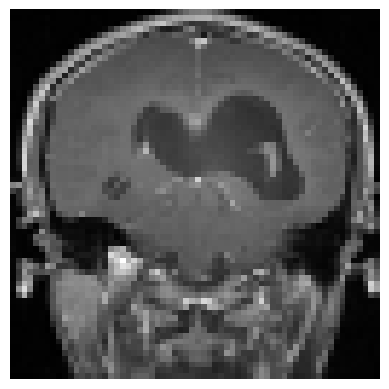

In [8]:
plt.imshow(x_train[2], cmap='gray')
plt.axis('off')
plt.show() 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


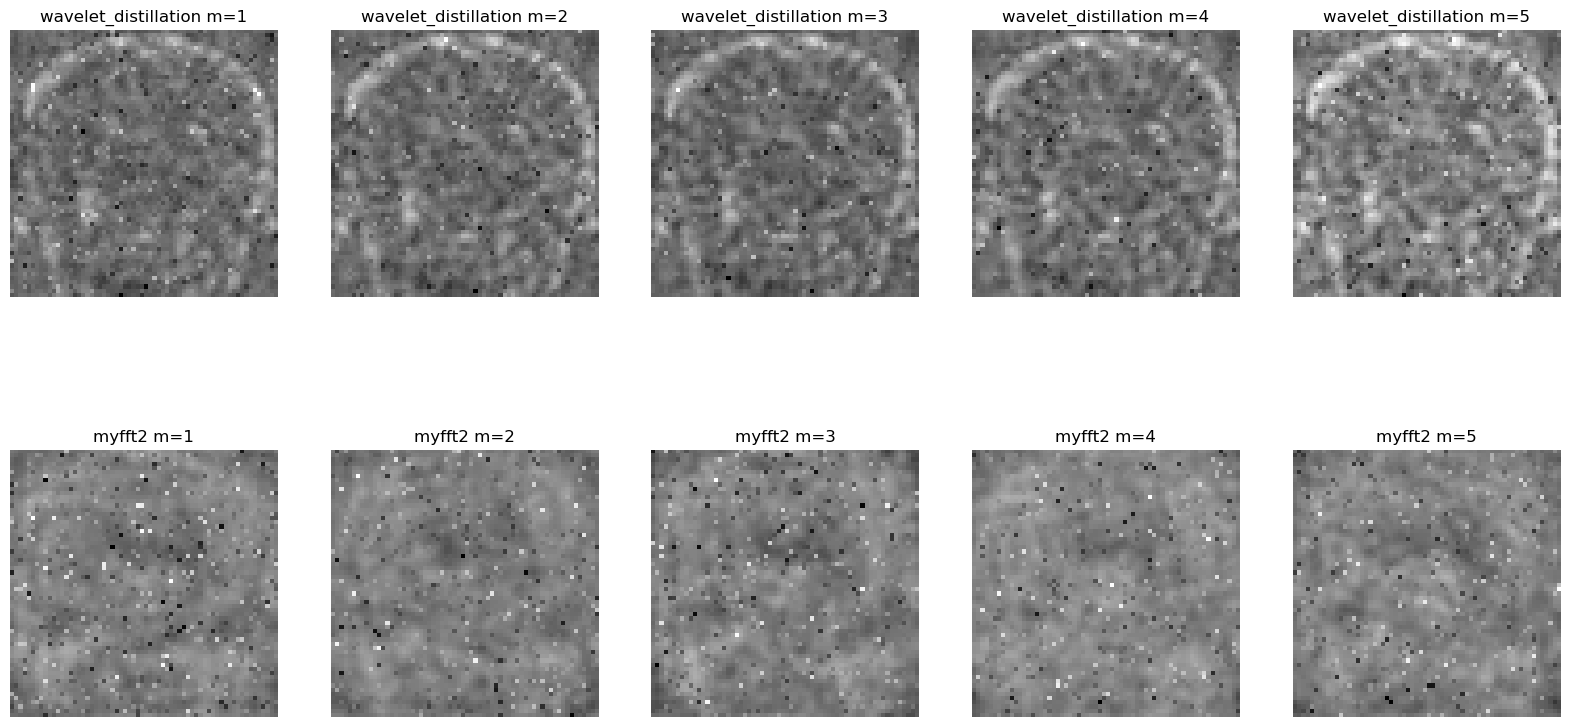

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()
img = []

for transform in [wavelet_distillation, myfft2]:
    for i in range(1, 6, 1):
        # --- ROBUST CUSTOM OBJECTS DICTIONARY ---
        # We map all possible conflicting strings (keys) to their current TensorFlow objects (values).
        CUSTOM_OBJECTS = {
            # 1. Metrics (Likely Source of Error)
            'keras.metrics.MSE': tf.keras.metrics.MeanSquaredError(),
            'MSE': tf.keras.metrics.MeanSquaredError(),
            'mse': tf.keras.metrics.MeanSquaredError(),
            
            # 2. Loss Functions (Possible Source of Error)
            'mean_squared_error': tf.keras.losses.MeanSquaredError(),
            
            # 3. Optimizers (Needed if you want to resume training, though not needed for prediction)
            'rmsprop': tf.keras.optimizers.RMSprop() 
        }


        # ---Loading Loop (Adjust the path as needed) ---

        # IMPORTANT: I'm using the fixed path structure from our previous conversation.
        model_path = f'/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/Wavelet/2pi/{transform.__name__}_m_{i}.keras'

        reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)


        # Load the same data you trained on (or new data) and run predictions
        X = generate_vortex_map(transform, np.array([x_train[2]]), m=i)

        recon_tumor = reconstruction_model.predict(X.reshape(1, -1)).reshape(DIM, DIM)
        img.append(recon_tumor)

        # Display the original and reconstructed images side by side
        ax = axes[(i-1) + (0 if transform == wavelet_distillation else 5)]
        ax.imshow(recon_tumor, cmap='gray')
        ax.set_title(f'{transform.__name__} m={i}')
        ax.axis('off')


plt.show()

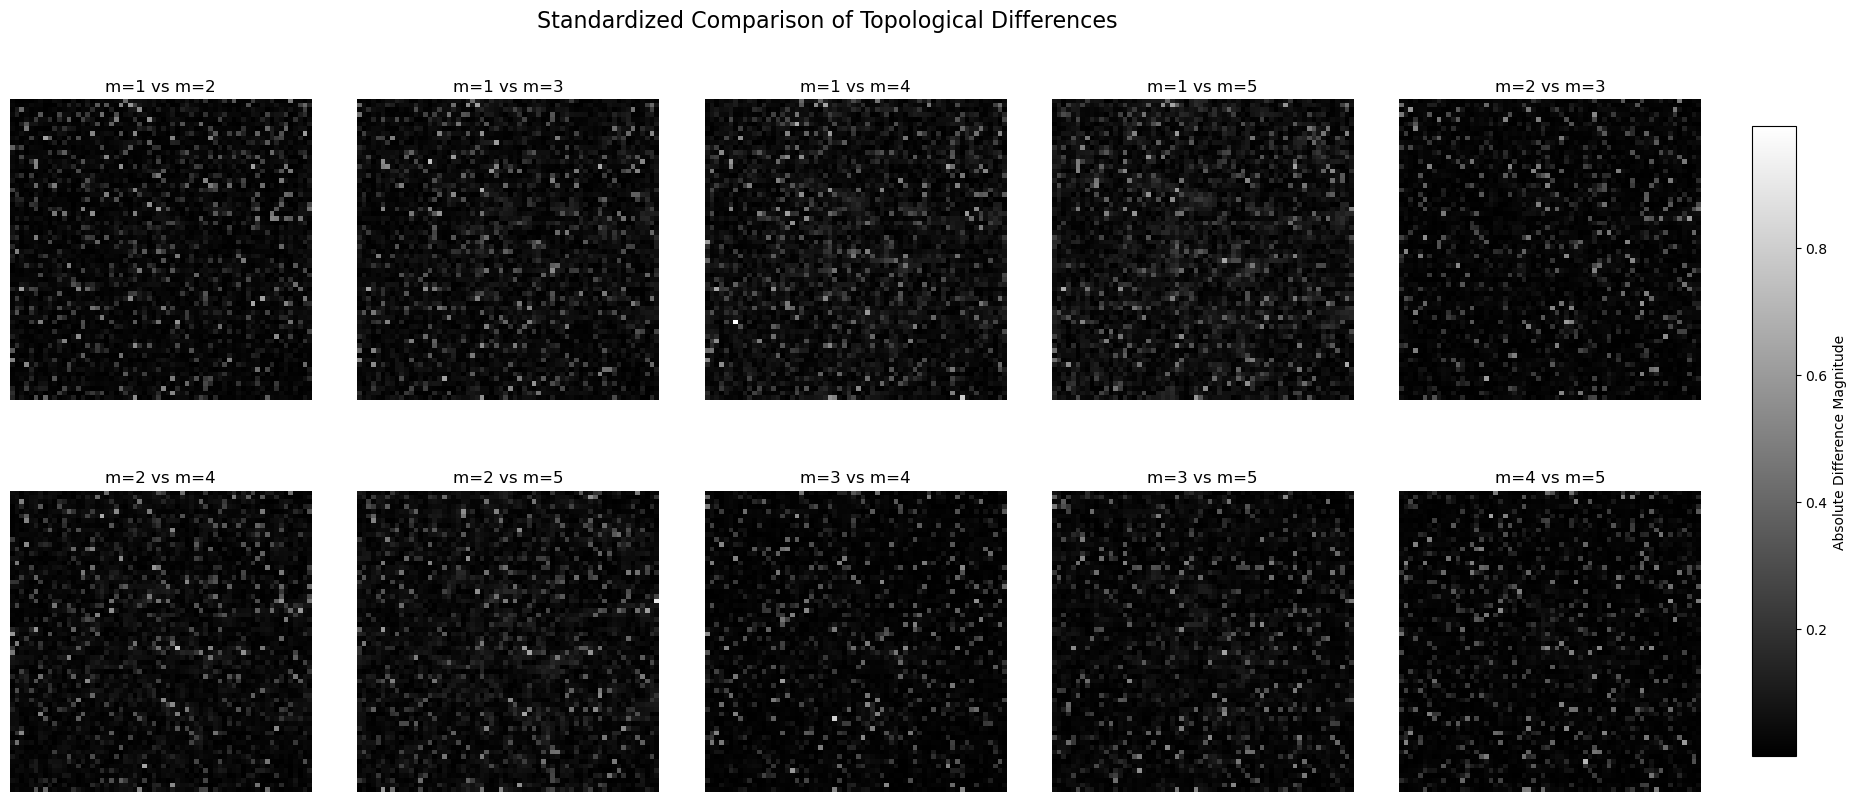

In [10]:
from itertools import combinations

# Assuming img is your array of shape (5, 64, 64)
# img[0] -> m=1, img[1] -> m=2, ..., img[4] -> m=5

def plot_shared_colorbar_differences(img_array):
    # 1. Generate combinations
    indices = list(combinations(range(5), 2))
    
    # 2. Calculate all differences first to find the global max
    # This ensures the colorbar represents the absolute scale of the data
    diffs = [np.abs(img_array[i] - img_array[j]) for i, j in indices]
    global_max = np.max(diffs)
    global_min = np.min(diffs)

    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    axes = axes.flatten()
    
    for i, (idx1, idx2) in enumerate(indices):
        # Plot with fixed vmin and vmax
        im = axes[i].imshow(diffs[i], cmap='gray', vmin=global_min, vmax=global_max)
        axes[i].set_title(f"m={idx1+1} vs m={idx2+1}", fontsize=12)
        axes[i].axis('off')

    # 3. Add one standard colorbar for the whole figure
    # 'shrink' and 'aspect' help the bar fit nicely next to the grid
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax, label='Absolute Difference Magnitude')

    plt.subplots_adjust(right=0.9, hspace=0.3, wspace=0.1)
    fig.suptitle("Standardized Comparison of Topological Differences", fontsize=16, y=0.98)
    plt.show()

# Run the function
plot_shared_colorbar_differences(img)

In [11]:
def process_entire_dataset(X_gt, f_distillation, m_range=[1, 2, 3, 4, 5]):
    """
    1. Generates vortex maps for the entire dataset.
    2. Passes them through the reconstruction model.
    3. Stores the reconstructed images for further Intra/Inter class analysis.
    """
    num_samples = X_gt.shape[0]
    # results shape: (5, num_samples, 64, 64)
    results = np.zeros((len(m_range), num_samples, 64, 64), dtype='float32')
    
    for idx, m_val in enumerate(m_range):
        print(f"\n--- Processing m = {m_val} ---")
        
        # 1. Generate the vortex maps for the whole batch
        # Output shape: (num_samples, 64, 64)
        X_vortex = generate_vortex_map(f_distillation, X_gt, m=m_val)
        
        # 2. Reshape for the Linear Model (N, 4096)
        X_flat = X_vortex.reshape(num_samples, 4096)
        
        # IMPORTANT: I'm using the fixed path structure from our previous conversation.
        model_path = f'/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/Wavelet/2pi/{f_distillation.__name__}_m_{m_val}.keras'

        reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)
        
        # 3. Predict the entire batch at once
        # Output shape: (num_samples, 4096)
        predictions_flat = reconstruction_model.predict(X_flat)
        
        # 4. Reshape back to (num_samples, 64, 64) and store
        results[idx] = predictions_flat.reshape(num_samples, 64, 64).astype('float32')
        
    return results

# Usage
all_reconstructions = process_entire_dataset(x_train, wavelet_distillation)


--- Processing m = 1 ---
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- Processing m = 2 ---
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Processing m = 3 ---
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Processing m = 4 ---
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Processing m = 5 ---
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [33]:
def analyze_class_separability(X_vortex, y_labels, i, num_pairs=100):
    # Indices for each class
    idx_infected = np.where(y_labels == i)[0]
    idx_normal = np.where(y_labels == 1)[0]
    
    intra_diffs = []
    inter_diffs = []

    for _ in range(num_pairs):
        # Intra-class: Infected Patient A vs Infected Patient B
        i1, i2 = np.random.choice(idx_infected, 2, replace=False)
        intra_diffs.append(np.abs(X_vortex[i1] - X_vortex[i2]))
        
        # Inter-class: Infected Patient A vs Normal Patient B
        j1 = np.random.choice(idx_infected)
        j2 = np.random.choice(idx_normal)
        inter_diffs.append(np.abs(X_vortex[j1] - X_vortex[j2]))

    # Calculate Mean Difference Maps
    mean_intra = np.mean(intra_diffs, axis=0)
    mean_inter = np.mean(inter_diffs, axis=0)
    
    return mean_intra, mean_inter


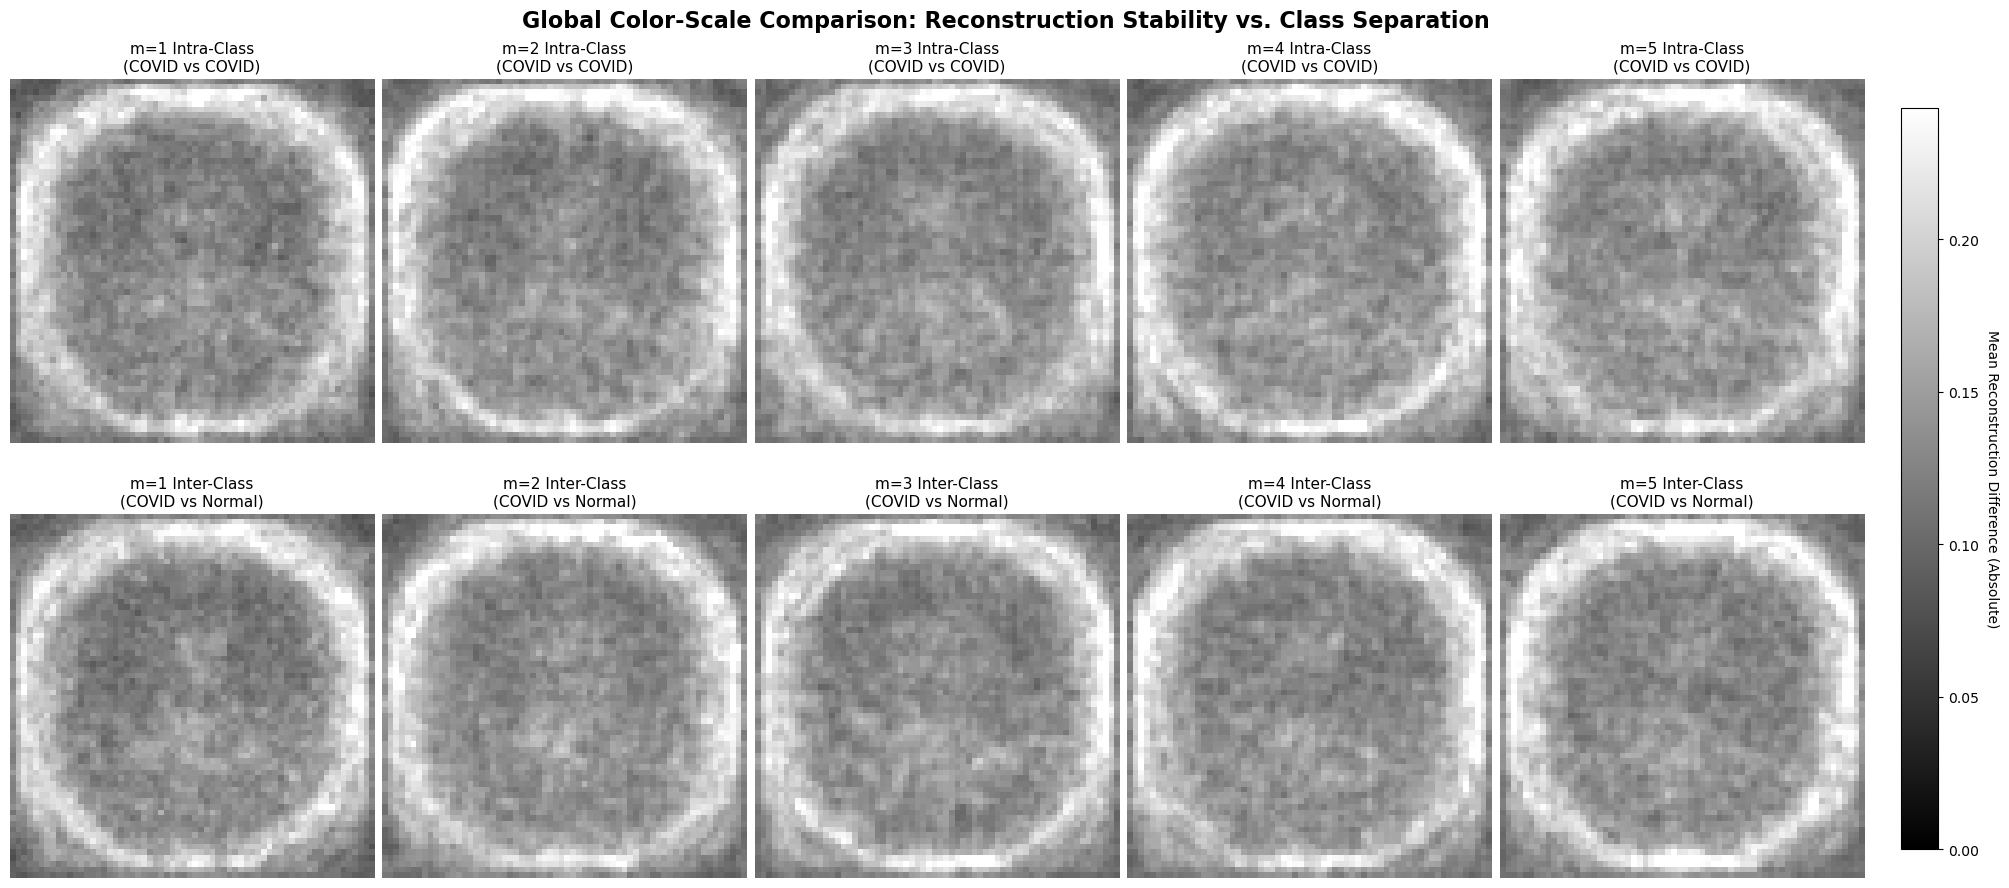

In [34]:
m5_intra, m5_inter = analyze_class_separability(all_reconstructions[4], y_train, i=0)
m1_intra, m1_inter = analyze_class_separability(all_reconstructions[0], y_train, i=0)
m2_intra, m2_inter = analyze_class_separability(all_reconstructions[1], y_train, i=0)
m3_intra, m3_inter = analyze_class_separability(all_reconstructions[2], y_train, i=0)
m4_intra, m4_inter = analyze_class_separability(all_reconstructions[3], y_train, i=0)


# 1. Organize your data
intra_list = [m1_intra, m2_intra, m3_intra, m4_intra, m5_intra]
inter_list = [m1_inter, m2_inter, m3_inter, m4_inter, m5_inter]
m_vals = [1, 2, 3, 4, 5]

# 2. Calculate Global Vmax (ignoring the top 2% of outliers for better contrast)
all_data = np.array(intra_list + inter_list)
global_vmax = np.percentile(all_data, 98)
global_vmin = 0  # Absolute difference is always positive

# 3. Create the Plot
fig, axes = plt.subplots(2, 5, figsize=(20, 9), constrained_layout=True)

for i in range(5):
    # --- Top Row: Intra-Class (Anatomical Variance) ---
    im_intra = axes[0, i].imshow(intra_list[i], cmap='gray', 
                                 vmin=global_vmin, vmax=global_vmax)
    axes[0, i].set_title(f"m={m_vals[i]} Intra-Class\n(COVID vs COVID)", fontsize=11)
    axes[0, i].axis('off')
    
    # --- Bottom Row: Inter-Class (Disease Signature) ---
    im_inter = axes[1, i].imshow(inter_list[i], cmap='gray', 
                                 vmin=global_vmin, vmax=global_vmax)
    axes[1, i].set_title(f"m={m_vals[i]} Inter-Class\n(COVID vs Normal)", fontsize=11)
    axes[1, i].axis('off')

# 4. Add a shared Colorbar
cbar = fig.colorbar(im_inter, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Reconstruction Difference (Absolute)', rotation=270, labelpad=15)

plt.suptitle("Global Color-Scale Comparison: Reconstruction Stability vs. Class Separation", 
             fontsize=16, fontweight='bold')

plt.show()

In [25]:
correlation = np.corrcoef(m5_inter.flatten(), m5_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

correlation = np.corrcoef(m4_inter.flatten(), m4_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

correlation = np.corrcoef(m3_inter.flatten(), m3_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

correlation = np.corrcoef(m2_inter.flatten(), m2_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

correlation = np.corrcoef(m1_inter.flatten(), m1_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

Correlation between Inter and Intra: 0.917720
Correlation between Inter and Intra: 0.923186
Correlation between Inter and Intra: 0.914233
Correlation between Inter and Intra: 0.927073
Correlation between Inter and Intra: 0.915127


In [35]:
m5_intra, m5_inter = analyze_class_separability(all_reconstructions[4], y_train, 3)
m1_intra, m1_inter = analyze_class_separability(all_reconstructions[0], y_train, 3)
m2_intra, m2_inter = analyze_class_separability(all_reconstructions[1], y_train, 3)
m3_intra, m3_inter = analyze_class_separability(all_reconstructions[2], y_train, 3)
m4_intra, m4_inter = analyze_class_separability(all_reconstructions[3], y_train, 3)


# 1. Organize your data
intra_list = [m1_intra, m2_intra, m3_intra, m4_intra, m5_intra]
inter_list = [m1_inter, m2_inter, m3_inter, m4_inter, m5_inter]
m_vals = [1, 2, 3, 4, 5]

# 2. Calculate Global Vmax (ignoring the top 2% of outliers for better contrast)
all_data = np.array(intra_list + inter_list)
global_vmax = np.percentile(all_data, 98)
global_vmin = 0  # Absolute difference is always positive

# 3. Create the Plot
fig, axes = plt.subplots(2, 5, figsize=(20, 9), constrained_layout=True)

for i in range(5):
    # --- Top Row: Intra-Class (Anatomical Variance) ---
    im_intra = axes[0, i].imshow(intra_list[i], cmap='gray', 
                                 vmin=global_vmin, vmax=global_vmax)
    axes[0, i].set_title(f"m={m_vals[i]} Intra-Class\n(VP vs VP)", fontsize=11)
    axes[0, i].axis('off')
    
    # --- Bottom Row: Inter-Class (Disease Signature) ---
    im_inter = axes[1, i].imshow(inter_list[i], cmap='gray', 
                                 vmin=global_vmin, vmax=global_vmax)
    axes[1, i].set_title(f"m={m_vals[i]} Inter-Class\n(VP vs Normal)", fontsize=11)
    axes[1, i].axis('off')

# 4. Add a shared Colorbar
cbar = fig.colorbar(im_inter, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Reconstruction Difference (Absolute)', rotation=270, labelpad=15)

plt.suptitle("Global Color-Scale Comparison: Reconstruction Stability vs. Class Separation", 
             fontsize=16, fontweight='bold')

plt.show()

ValueError: 'a' cannot be empty unless no samples are taken

In [38]:
unique, counts = np.unique(y_train, return_counts=True)
label_names = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

for u, c in zip(unique, counts):
    # Convert u from float64 to int
    idx = int(u)
    name = label_names[idx] if idx < len(label_names) else "Unknown"
    print(f"Index {idx} ({name}): {c} images found")

Index 0 (COVID): 17136 images found
Index 1 (Normal): 5712 images found
